CLUSTERING K-MEANS

Importar librerías

In [22]:
%matplotlib inline
from sklearn.datasets import make_blobs
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering

import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

Cargar datos

In [23]:
#Cargar datos
path = os.path.join('df_final.csv')
df = pd.read_csv(path)

In [24]:
#Seleccionar solo columnas numéricas
df_numericas = df.select_dtypes(include = np.number)
print("Variables numéricas:", df_numericas.shape)

Variables numéricas: (53747, 17)


In [25]:
# ================================
# 2. ESCALADO DE VARIABLES
# ================================
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numericas)


In [30]:
#Realizar PCA en 2D
from sklearn.decomposition import PCA
def plot_clusters(df_numericas, labels, title):
    pca = PCA(n_components=2)
    X2 = pca.fit_transform(df_numericas)

    plt.figure(figsize=(7,5))
    sns.scatterplot(
        x=X2[:,0],
        y=X2[:,1],
        hue=labels,
        palette="tab10",
        s=45
    )
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.show()

    return pca

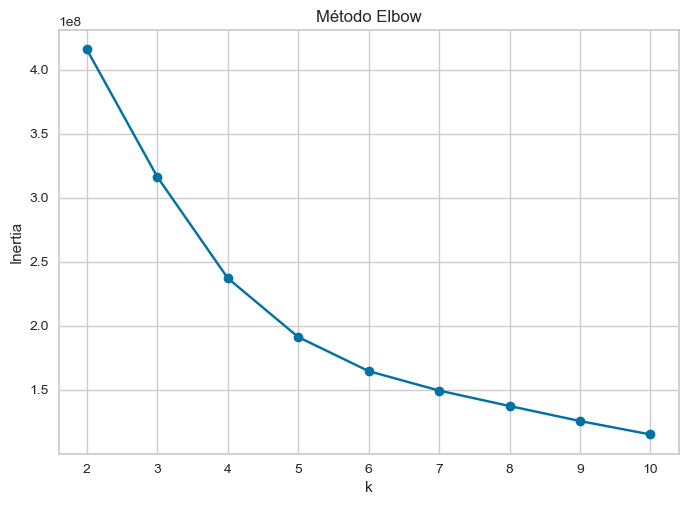

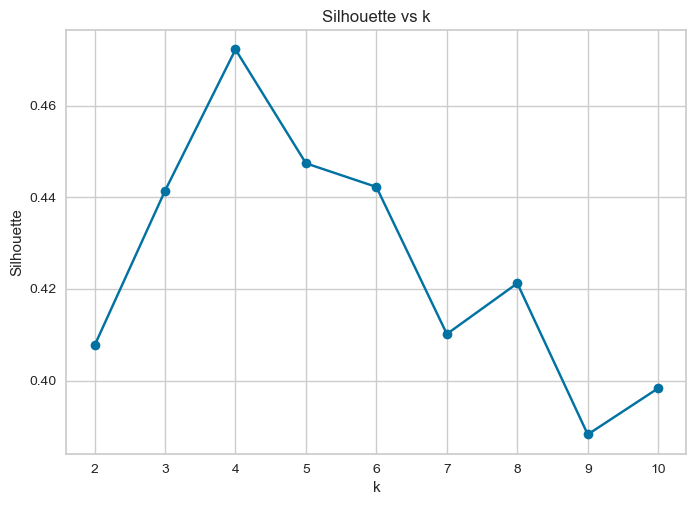

In [ ]:
#Realizar el método del codo y calcular el índice de silueta
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

#K-MEANS 
k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=42)
    etiquetas = modelo.fit_predict(df_numericas)
    inertias.append(modelo.inertia_)
    silhouettes.append(silhouette_score(df_numericas, etiquetas))

#Método del codo
plt.plot(k_values, inertias, '-o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Método del Codo")
plt.show()

#Índice de silueta
plt.plot(k_values, silhouettes, '-o')
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette vs k")
plt.show()


GRÁFICO DISTRIBUCIÓN CLUSTERS


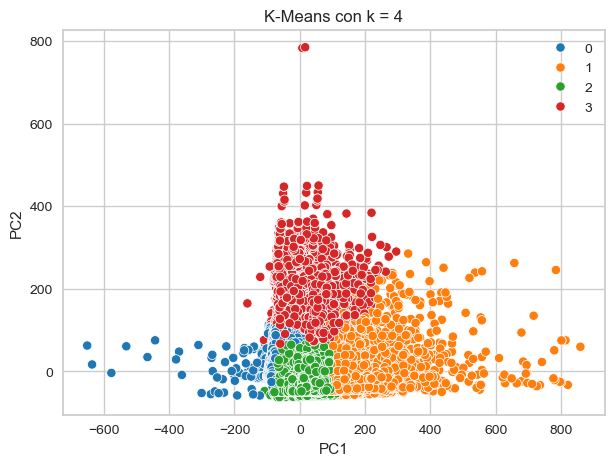

PCA(n_components=2)

In [36]:
#K-MEANS con el k del método del codo
k_final = 4  
kmeans = KMeans(n_clusters = k_final, n_init = 10, random_state = 42)
labels_kmeans = kmeans.fit_predict(df_numericas)

print("GRÁFICO DISTRIBUCIÓN CLUSTERS")
plot_clusters(df_numericas, labels_kmeans, f"K-Means con k = {k_final}")

CLUSTERING JERÁRQUICO:

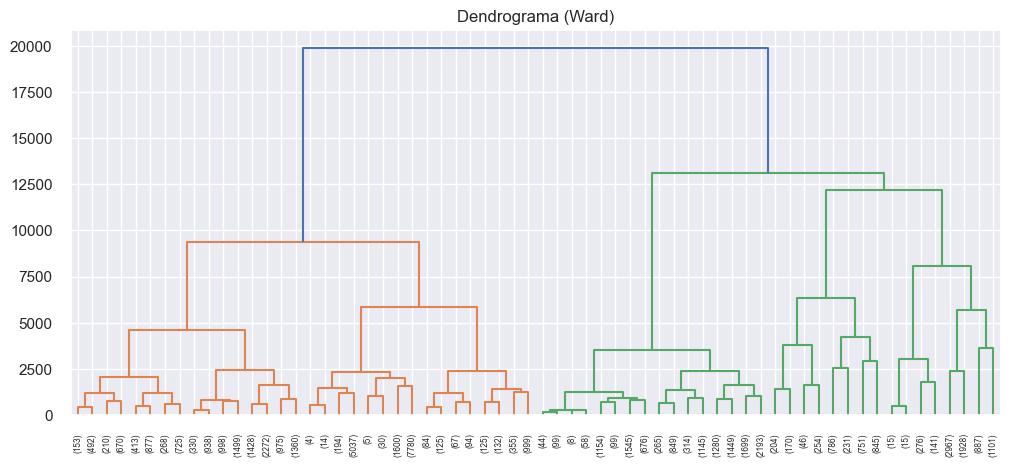

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
#CLUSTERING JERÁRQUICO (WARD)
#Dendrograma
Z = linkage(df_numericas, method = 'ward')

plt.figure(figsize=(12,5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Dendrograma (Ward)")
plt.show()


=== Métricas Jerárquico (Ward) ===
{'Silhouette Score': np.float64(0.41814873190311797), 'Davies-Bouldin Index': np.float64(1.067261563519525), 'Calinski-Harabasz Index': np.float64(23634.144311069125)}


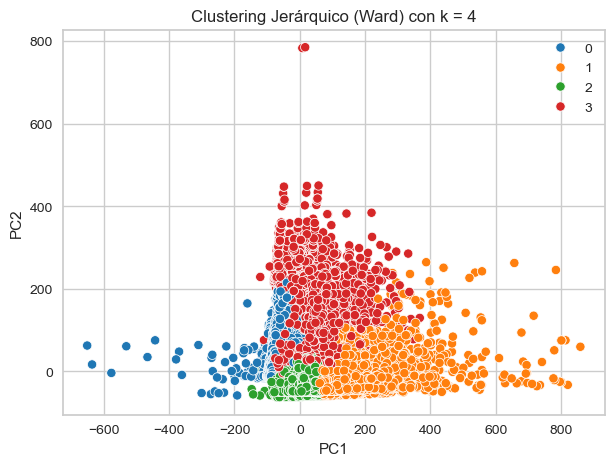

In [19]:
#Clustering Jerárquico final con el método del codo
k_hier = 4 
jerarquico = AgglomerativeClustering(n_clusters = k_hier, linkage = 'ward')
labels_hier = jerarquico.fit_predict(df_numericas)

print("\n=== Métricas Jerárquico (Ward) ===")
plot_clusters(df_numericas, labels_hier, f'Clustering Jerárquico (Ward) con k = {k_hier}')

DBSCAN

In [35]:
from sklearn.cluster import DBSCAN

y_clusters = DBSCAN(eps = 0.5, min_samples = 3).fit_predict(df_numericas)
#eps (epsilon) indica el radio de la circunferencia
print(y_clusters)

[-1 -1 -1 ... -1 -1 -1]


In [ ]:
#MÉTODOS DE EVALUACIÓN
def evaluar_clustering(df_numericas, etiquetas):
    """Devuelve métricas para comparar particiones."""
    silhouette = silhouette_score(df_numericas, etiquetas)
    db = davies_bouldin_score(df_numericas, etiquetas)
    ch = calinski_harabasz_score(df_numericas, etiquetas)

    return {
        "Silhouette": silhouette,
        "Davies-Bouldin": db,
        "Calinski-Harabasz": ch
    }

ÍNDICE DE SILUETA:
- De -1 a 1
- Cuanto más alto, mejor

ÍNDICE DAVIES-BOULDIN (DBI):
- de 0 a ∞
- Cuanto más bajo, mejor

ÍNDICE CALINSKI-HARABASZ (CH):
- No hay escala fija
- Cuanto más alto, mejor

In [ ]:
#COMPARACIÓN FINAL
print("\n===== COMPARACIÓN FINAL =====")
print("K-MEANS:", evaluar_clustering(df_numericas, labels_kmeans))
print("JERÁRQUICO:", evaluar_clustering(df_numericas, labels_hier))


===== COMPARACIÓN FINAL =====
K-MEANS: {'Silhouette': np.float64(0.4473899571736851), 'Davies-Bouldin': np.float64(0.8329465166662068), 'Calinski-Harabasz': np.float64(30682.16682175056)}
JERÁRQUICO: {'Silhouette': np.float64(0.3880711325627126), 'Davies-Bouldin': np.float64(1.0343976451002799), 'Calinski-Harabasz': np.float64(23778.071082728384)}


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numericas)

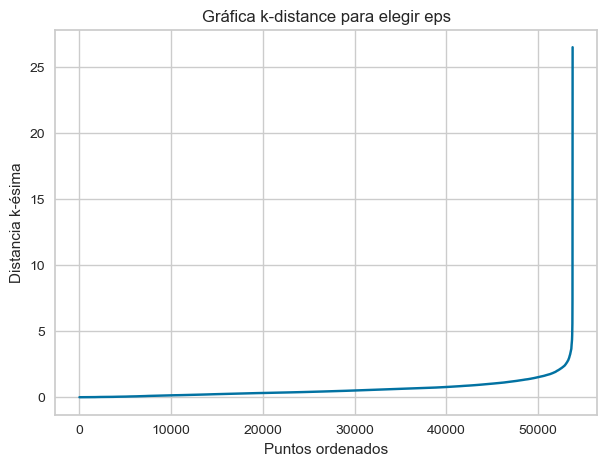

In [38]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

k = 4  # suele ser min_samples
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

distances = np.sort(distances[:, k-1])

plt.figure(figsize=(7,5))
plt.plot(distances)
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia k-ésima")
plt.title("Gráfica k-distance para elegir eps")
plt.show()


In [39]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)  # ajusta eps según la gráfica
labels_dbscan = dbscan.fit_predict(df_scaled)

In [40]:
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)

print("Clusters encontrados:", n_clusters)
print("Puntos de ruido:", n_noise)

Clusters encontrados: 407
Puntos de ruido: 12017


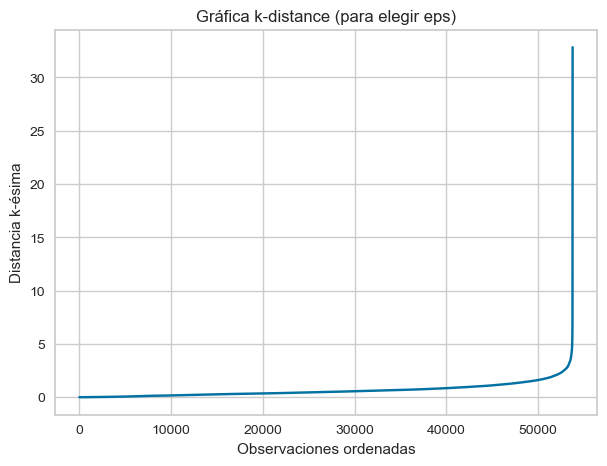

Clusters encontrados: 407
Puntos considerados ruido: 12017


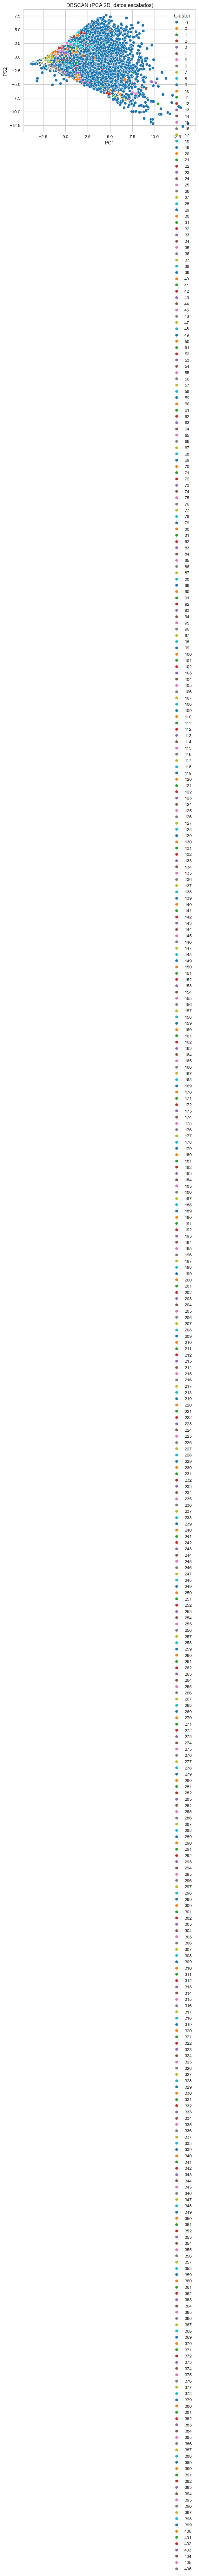

Varianza explicada por PCA: [0.20135244 0.15101861]
Varianza total: 0.3523710507240093
Silhouette: 4.649807863359222e-05


In [41]:
# ======================================
# 1. LIBRERÍAS
# ======================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# ======================================
# 2. ESCALADO DE VARIABLES (OBLIGATORIO)
# ======================================
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numericas)

# ======================================
# 3. FUNCIÓN PARA VISUALIZAR CLUSTERS (PCA 2D)
# ======================================
def plot_clusters(data, labels, title):
    pca = PCA(n_components=2)
    X2 = pca.fit_transform(data)

    plt.figure(figsize=(7,5))
    sns.scatterplot(
        x=X2[:, 0],
        y=X2[:, 1],
        hue=labels,
        palette="tab10",
        s=45
    )
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Cluster")
    plt.show()

    return pca

# ======================================
# 4. ELECCIÓN DE eps (k-distance plot)
# ======================================
k = 5  # suele coincidir con min_samples
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

# Distancia al k-ésimo vecino
distances = np.sort(distances[:, k-1])

plt.figure(figsize=(7,5))
plt.plot(distances)
plt.xlabel("Observaciones ordenadas")
plt.ylabel("Distancia k-ésima")
plt.title("Gráfica k-distance (para elegir eps)")
plt.show()

# ======================================
# 5. DBSCAN
# ======================================
eps_value = 0.8   # ajustar según el codo del gráfico
min_samples = 5

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(df_scaled)

# ======================================
# 6. NÚMERO DE CLUSTERS Y RUIDO
# ======================================
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)

print("Clusters encontrados:", n_clusters)
print("Puntos considerados ruido:", n_noise)

# ======================================
# 7. VISUALIZACIÓN FINAL
# ======================================
pca_model = plot_clusters(
    df_scaled,
    labels_dbscan,
    "DBSCAN (PCA 2D, datos escalados)"
)

print("Varianza explicada por PCA:", pca_model.explained_variance_ratio_)
print("Varianza total:", pca_model.explained_variance_ratio_.sum())

# ======================================
# 8. MÉTRICA (SI ES POSIBLE)
# ======================================
if n_clusters > 1:
    print("Silhouette:", silhouette_score(df_scaled, labels_dbscan))
else:
    print("No se puede calcular silhouette (menos de 2 clusters)")
